Scrieţi un program în Python care să preia ca input un fişier .csv cu o listă oarecare şi să aibă ca output un număr
predeterminat de elemente din acea listă, fără repetiţie. Aplicaţi pe lista studenţilor din grupa dumneavoastră care nu
au prezentat încă o temă.

In [3]:
import csv
import random

def extrage_studenti(fisier_csv, k):
    studenti = []
    with open(fisier_csv,mode='r',encoding='utf-8') as f:
        reader = csv.reader(f)
        for linie in reader:
            if linie:
                studenti.append(linie[0].strip())

    if k>len(studenti):
        raise ValueError(f"Numarul cerut ({k}) depaseste totalul studentilor ({len(studenti)}).")

    selectati = random.sample(studenti,k)

    return selectati

rezultat = extrage_studenti("studenti.csv",3)
print("Studentii:")
for i,student in enumerate(rezultat, 1):
    print(f"{i}. {student}")

Studentii:
1. Georgescu Andrei
2. Radu Elena
3. Dumitru Vlads


Doi prieteni joacă următorul joc, după următoarele reguli:
Pasul 1. Primul jucător aruncă cu o monedă.
● Dacă pică stemă, cel de-al doilea trebuie să arunce cu zarul şi să-i dea primului o sumă egală z − 3 $, unde z
este rezultatul aruncării cu zarul (a da o sumă negativă este echivalent cu a lua opusul acelei sume). Jocul
se încheie aici.
● Dacă pică ban, atunci primul jucător trebuie să-i dea celui de-al doilea 0.5 $.
Pasul n. În caz că jocul nu s-a încheiat, se reia pasul 1.
Astfel, jocul se opreşte la pasul corespunzător obţinerii stemei de către primul jucător.

a)Ce fel de distribuţie urmează N, numărul de paşi ai jocului?
La fiecare pas se arunca o moneda o singura data, o probă Bernoulli cu probabilitatea de succes p = 0,5 pentru o monedă echilibrată.
N reprezinta numarul de incercari pana la primul succes (pana banul va arata stema),inclusiv incercarea cu reusita.
Prin urmare, N urmeaza o distributie geometrica pe suportul {1,2,3,...}: N~Geom(p)
P(N=k)=(1-p)^(k-1)*p    k apartine {1,2,3,...}

Inainte de pasul N, moneda a cazut de N-1 ori pe ban. De fiecare data primul ii da celui de al doilea 0.5$, deci primul pierde (N-1)*0.5$.
La pasul N, cade stema. Al doilea da cu zarul (z {1,2,3,4,5,6}) si ii da primului suma z-3$.
Deci suma primita de primul jucator este (z-3)-0.5*(N-1)

b) Simulaţi în Python un astfel de joc. Variabilele care ne interesează sunt N şi suma totală S pe care cel de-al
doilea jucător trebuie să i-o dea primului.

In [7]:
import numpy as np

def simulare_joc(p=0.5):
    pas=0
    valoare_primita=0

    while True:
        pas+=1
        if np.random.rand() < p:
            zar= np.random.randint(1,7)
            valoare_primita+=(zar-3)
            break
        else:
            valoare_primita-=0.5

    return pas,valoare_primita

pasi,valoare=simulare_joc()
print(pasi,",",valoare)

1 , 3


c) Prin simularea unui număr mare de astfel de jocuri, determinaţi cu aproximaţie media lui S şi reprezentaţi grafic
(printr-o histogramă) distribuţia acesteia.

Număr de jocuri: 100000
Probabilitate stemă (p): 0.5
Media estimată a sumei S: -0.0020 $


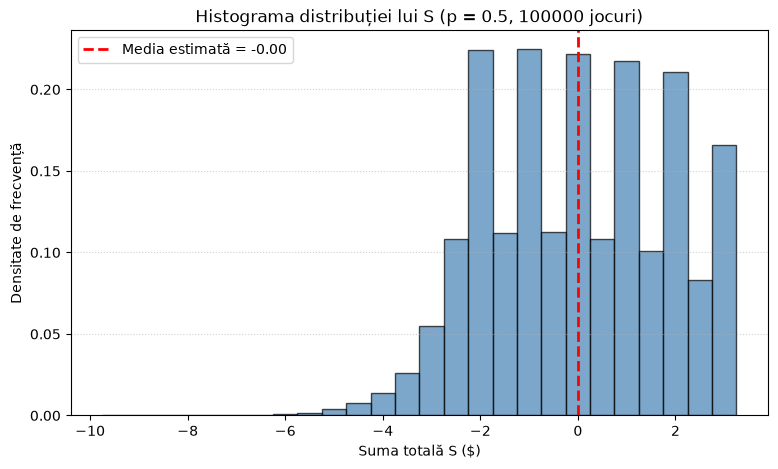

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def analiza_jocuri(numar_jocuri=100000,p=0.5):
    Valori_N = []
    Valori_S = []

    for _ in range(numar_jocuri):
        n,s= simulare_joc(p)
        Valori_N.append(n)
        Valori_S.append(s)

    valori_S=np.array(Valori_S)
    media_valorilor=np.mean(valori_S)
    print(f"Număr de jocuri: {numar_jocuri}")
    print(f"Probabilitate stemă (p): {p}")
    print(f"Media estimată a sumei S: {media_valorilor:.4f} $")

    plt.figure(figsize=(9, 5))
    bins = np.arange(np.min(valori_S)-0.25,np.max(valori_S)+0.75,0.5)
    plt.hist(valori_S, bins=bins, density=True, edgecolor='black', alpha=0.7, color='steelblue')
    plt.axvline(media_valorilor, color='red', linestyle='--', linewidth=2, label=f'Media estimată = {media_valorilor:.2f}')
    
    plt.title(f"Histograma distribuției lui S (p = {p}, {numar_jocuri} jocuri)")
    plt.xlabel("Suma totală S ($)")
    plt.ylabel("Densitate de frecvență")
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()
analiza_jocuri(100000,0.5)

d) Ce se întâmplă dacă moneda este măsluită? Încercaţi să refaceţi pct. c) cu o probabilitate de apariţie a stemei
p = 0.3, respectiv p = 0.7.

p=0.3

Număr de jocuri: 100000
Probabilitate stemă (p): 0.3
Media estimată a sumei S: -0.6709 $


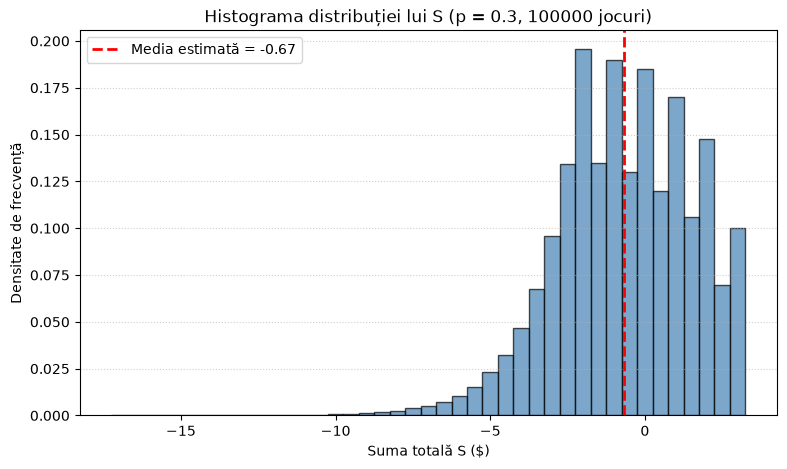

In [9]:
analiza_jocuri(100000,0.3)

p=0.7

Număr de jocuri: 100000
Probabilitate stemă (p): 0.7
Media estimată a sumei S: 0.2812 $


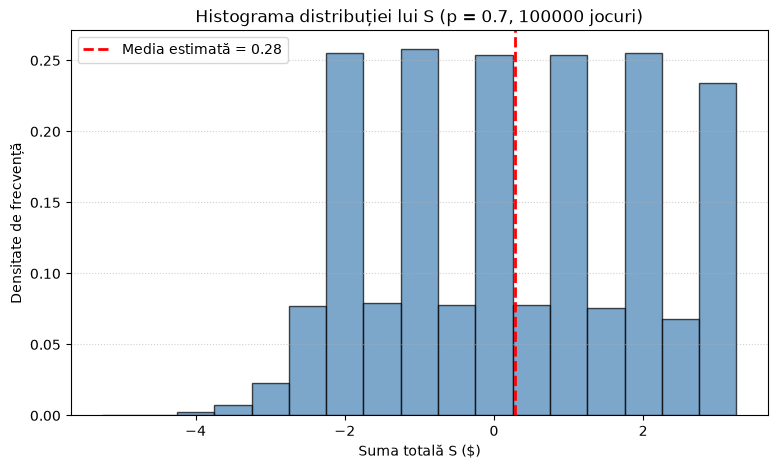

In [10]:
analiza_jocuri(100000,0.7)

Pentru p = 0.3 (stema apare greu): N creste in medie la 1/0.3 ~ 3.33 pasi. Primul jucator plateste de mai multe ori cste 0.5$, deci media devine negativa aprox -0.67. Histograma se lateste si se muta spre stanga (joc clar în dezavantajul primului).
Pentru p = 0.7 (stema apare des): jocul se opreste adesea din prima sau a doua aruncare aprox 1.43. Primul jucator pierde rar banuti de 0.5$, deci media devine pozitiva aprox +0.29$. Histograma se ingusteaza si se impinge spre dreapta.

Ex3.Într-o frizerie, trei frizeri îşi tund clienţii cu următoarele viteze medii: primul cu 3 clienţi pe oră, al doilea cu 6 pe
oră iar al treilea cu 4 pe oră. Astfel, timpul de servire al unui client este modelat de distribuţii exponenţiale cu parametrii
λ1 = 3 h−1
, λ2 = 6 h−1
, respectiv λ3 = 4 h−1

, iar probabilităţile de preluare a unui client de către un anumit frizer sunt

3/13, 6/13, respectiv 4/13 (de ce?). Fie X timpul de servire pentru un client.
Generaţi 10000 de valori pentru X, şi în felul acesta estimaţi media şi deviaţia standard a lui X. Realizaţi un grafic
aproximativ al densităţii distribuţiei lui X.

Intr-un sistem in regim stationar (sau cand frizerii se elibereaza continuu conform proceselor Poisson), rata totala cu care frizeria preia/eliberează clienti este:
Lambda = lambda_1 + lambda_2 + lambda_3 = 3 + 6 + 4 = 13 clienti/ora
Frizerul mai rapid finalizeaza mai multi clienti pe unitate de timp, deci se elibereaza mai des. Sansa ca urmatorul frizer liber sa fie frizerul i este proportionala cu viteza sa de lucru:
pi=lambdai/Lambda deci p1=3/13, p2=6/13, p3=4/13

Media estimata a lui X: 0.2305 ore (13.83 minute)
Deviatia standard estimata: 0.2423 ore (14.54 minute)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

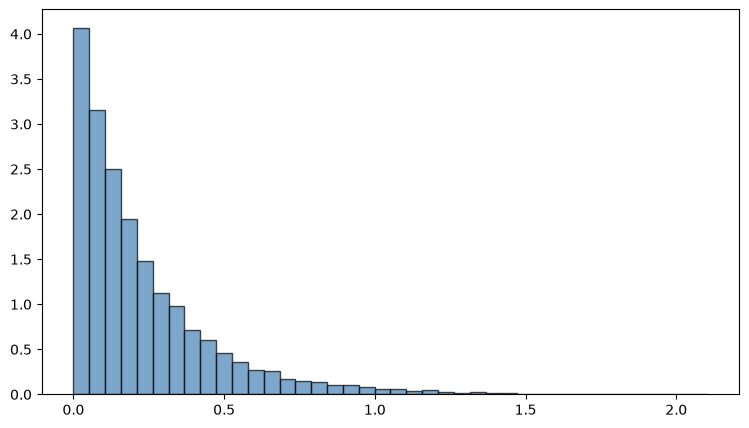

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from scipy.stats import gaussian_kde

lambdas = np.array([3.0, 6.0, 4.0])
probabilitati = np.array([3/13, 6/13, 4/13])
N = 10000

frizer_ales=np.random.choice([0,1,2],size=N,p=probabilitati)
rate_alocate=lambdas[frizer_ales]
x=np.random.exponential(scale=1.0/rate_alocate)

media_X=np.mean(x)
std_X=np.std(x)

print(f"Media estimata a lui X: {media_X:.4f} ore ({media_X * 60:.2f} minute)")
print(f"Deviatia standard estimata: {std_X:.4f} ore ({std_X * 60:.2f} minute)")

plt.figure(figsize=(9, 5))
plt.hist(
    x,
    bins=40,
    density=True,
    alpha=0.7,
    color="steelblue",
    edgecolor="black",
    label="Densitate estimată"
)
x_grid = np.linspace(x.min(), x.max(), 500)
densitate_kde = gaussian_kde(x)(x_grid)

plt.plot(
    x_grid,
    densitate_kde,
    color="darkblue",
    linewidth=2,
    label="Densitate KDE"
)
plt.title("Densitatea aproximativă a timpului de servire X (10000 eșantioane)")
plt.xlabel("Timp de servire X (ore)")
plt.ylabel("Densitate de probabilitate")
plt.axvline(media_X, color='red', linestyle='--', label=f'Media = {media_X:.3f} h')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()